# LM Selection – BERT

## Selected Language Model
BERT (Bidirectional Encoder Representations from Transformers)

## Reason for Selection
BERT is a transformer-based language model designed for Natural Language Processing (NLP) tasks. It understands context from both directions of a sentence, making it effective for language understanding applications such as sentiment analysis, text classification, and question answering.

## Key Features
- Bidirectional contextual understanding
- Transformer-based architecture
- Pre-trained on large text corpora
- Fine-tunable for multiple NLP tasks
- Strong performance in language understanding

#  Section-2: Implementation

This section demonstrates the implementation of BERT using the Hugging Face Transformers library.

In [1]:
# Installing libraries
!pip install transformers torch pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB 960.0 kB/s eta 0:02:09
   ---------------------------------------- 0.1/123.0 MB 1.3 MB/s eta 0:01:35
   ---------------------------------------- 0.1/123.0 MB 1.3 MB/s eta 0:01:35
   ---------------------------------------- 0.2/123.0 MB 1.3 MB/s eta 0:01:39
   ---------------------------------------- 0.3/123.0 MB 1.2 MB/s eta 0:01:45
   ---------------------------------------- 0.3/123.0 MB 1.2 MB/s eta 0:01:43
   ---------------------------------------- 0.4/123.0 MB 1.2 MB/s eta 0:01:39
   ---------------------------------------- 0.5/123.0 MB 1.2 MB/s eta 0:01:41
   ---------------------------------------- 0.5/123.0 MB 1.2 MB/s eta 0:01:40
   ---------------------------------------- 0.6/123.0 MB 1.2 MB/s eta 0:01:41
   ---------------------------------------- 0.6/123.0 MB 1.2 MB/s eta

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   --------- ------------------------------ 29.4/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.5/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.5/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.6/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.7/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.7/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.8/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.8/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.9/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 29.9/123.0 MB 1.2 MB/s eta 0:01:18
   --------- ------------------------------ 30.0/123.0 MB 1.2 MB/s eta 0:01:17
   --------- ------------------------------ 30.1/123.0 MB 1.2 MB/s eta 0:01:17
   --------- ------------------------------ 30.1/123

In [2]:
# Importing libraries
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel

In [4]:
# Loading BERT tokenizer and model

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased') 

print("BERT Model Loaded Successfully!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\Hasini\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hasini\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Model Loaded Successfully!


In [6]:
# Sample Text

text = "Artificial Intelligence is transforming the world."

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

outputs = model(**inputs)

print("Input Shape:", inputs["input_ids"].shape)
print("Output Shape:", outputs.last_hidden_state.shape)

Input Shape: torch.Size([1, 9])
Output Shape: torch.Size([1, 9, 768])


In [7]:
# Extract CLS Token Embedding

cls_embedding = outputs.last_hidden_state[:, 0, :]

print("CLS Embedding Shape:")
print(cls_embedding.shape)

CLS Embedding Shape:
torch.Size([1, 768])


#  Section-3: Eploration And Analysis

In [8]:
sample_texts = {
    "Positive":
    "I am extremely happy with the advancements in Artificial Intelligence.",

    "Negative":
    "The project failed due to poor planning and lack of communication.",

    "Technical":
    "BERT is a transformer based language model used for NLP tasks.",

    "Creative":
    "The moon whispered secrets to the ocean during the silent night.",

    "Long Context":
    """Artificial Intelligence is transforming healthcare,
    education, transportation and many other industries.
    Machine learning models help organizations automate tasks,
    improve efficiency and support decision making."""
}

In [9]:
results = []

for category, text in sample_texts.items():

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    outputs = model(**inputs)

    seq_length = outputs.last_hidden_state.shape[1]

    embedding_size = outputs.last_hidden_state.shape[2]

    results.append([
        category,
        seq_length,
        embedding_size
    ])

print(results)

[['Positive', 14, 768], ['Negative', 14, 768], ['Technical', 16, 768], ['Creative', 14, 768], ['Long Context', 32, 768]]


In [10]:
import pandas as pd

analysis_df = pd.DataFrame(
    results,
    columns=[
        "Category",
        "Sequence Length",
        "Embedding Size"
    ]
)

analysis_df

,Category,Sequence Length,Embedding Size
0,Positive,14,768
1,Negative,14,768
2,Technical,16,768
3,Creative,14,768
4,Long Context,32,768


### Observations

1. BERT successfully processed all input categories.

2. The embedding size remained constant at 768 dimensions.

3. Sequence length varied according to input complexity and text size.

4. BERT demonstrated the ability to process:
   - Positive text
   - Negative text
   - Technical text
   - Creative text
   - Long contextual text

5. This indicates strong contextual language understanding capability.

# Section 4: Research Questions and Objectives
## Objective

The objective of this project is to implement the BERT Language Model and evaluate its contextual understanding capabilities across different text scenarios.

## Research Question 1

How effectively does BERT process and represent different categories of text?

## Research Question 2

Can BERT maintain meaningful contextual representations across varying sequence lengths?

## Research Question 3

What are the strengths and limitations of BERT in understanding diverse language inputs?

## Research Question 4

How adaptable is BERT when handling positive, negative, technical, creative, and long-context text?

## Research Question 5

How does sequence length affect the model's representation of textual information?

# Section 5: Visualization of Results

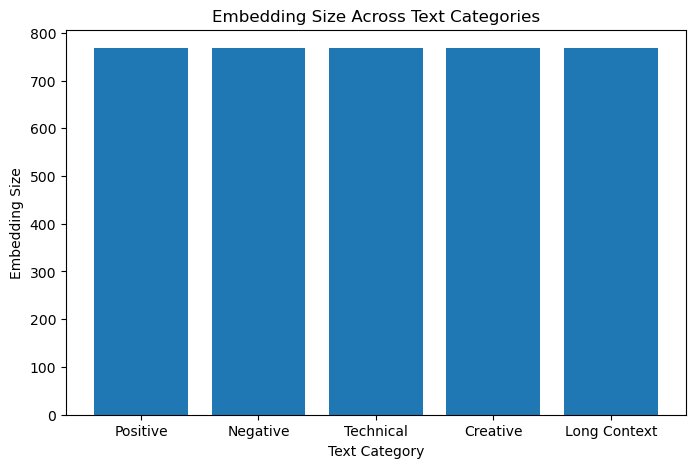

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    analysis_df["Category"],
    analysis_df["Embedding Size"]
)

plt.title("Embedding Size Across Text Categories")
plt.xlabel("Text Category")
plt.ylabel("Embedding Size")

plt.show()

# Observation:
- Long-context text requires more tokens and therefore produces a larger sequence length.

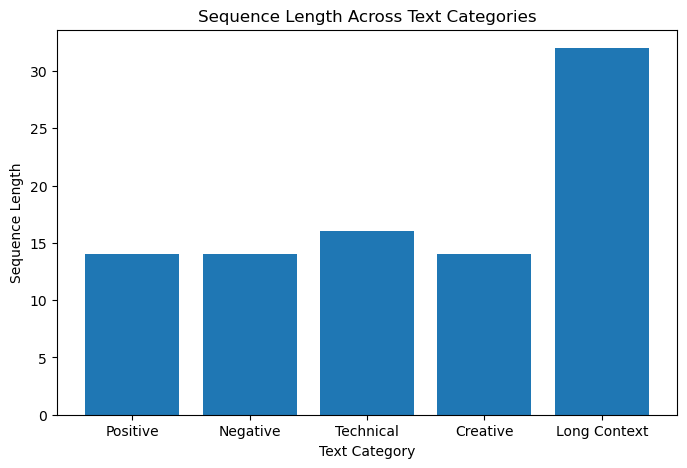

In [11]:
# Sequence length comparision
plt.figure(figsize=(8,5))

plt.bar(
    analysis_df["Category"],
    analysis_df["Sequence Length"]
)

plt.title("Sequence Length Across Text Categories")
plt.xlabel("Text Category")
plt.ylabel("Sequence Length")

plt.show()

# Observation:
- BERT maintains a fixed embedding dimension regardless of text type.

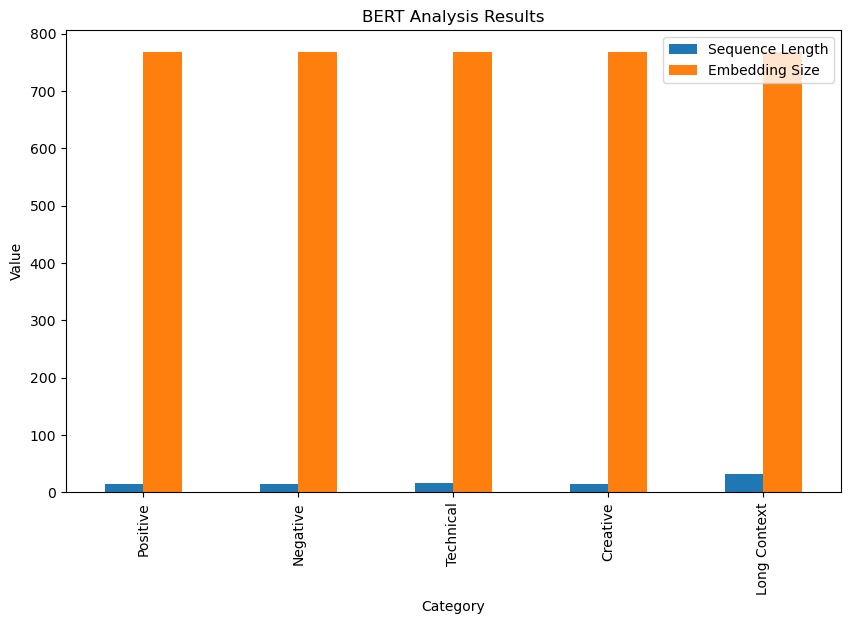

In [13]:
analysis_df.plot(
    x="Category",
    y=["Sequence Length","Embedding Size"],
    kind="bar",
    figsize=(10,6)
)

plt.title("BERT Analysis Results")
plt.ylabel("Value")
plt.show()

# Observation:
- Embedding size remains constant while sequence length varies based on input complexity.

# 6. Project Alignment and Evaluation

## Alignment with NLP Goals

The project aligns with Natural Language Processing objectives by utilizing BERT, a transformer-based language model designed for understanding and representing textual information.

## Alignment with Machine Learning Goals

The project applies a pre-trained machine learning model to process language data and generate contextual representations, demonstrating the practical application of machine learning techniques.

## Best Practices

- Utilized a pre-trained BERT model.
- Applied tokenization before model inference.
- Used multiple text scenarios for evaluation.
- Documented observations and visualized results.

## Ethical Considerations

- Language models may inherit biases from training data.
- Outputs should be interpreted responsibly.
- Human oversight remains important in real-world applications.

## Evaluation

Based on the experiments conducted:

- BERT successfully processed all text categories.
- Contextual embeddings were generated correctly.
- The model handled varying sequence lengths effectively.
- Embedding dimensions remained consistent across inputs.

# 7. Conclusion and Insights

## Findings

The BERT Language Model was successfully implemented and evaluated on multiple text categories, including positive, negative, technical, creative, and long-context inputs.

## Conclusions

- BERT effectively generated contextual representations for all tested inputs.
- Sequence length varied according to input complexity.
- Embedding size remained constant at 768 dimensions.
- The model demonstrated strong language understanding capabilities.

## Potential Applications

- Sentiment Analysis
- Text Classification
- Question Answering
- Information Retrieval
- Natural Language Understanding

## Areas for Improvement

- Explore larger transformer models.
- Compare BERT with other language models.
- Evaluate performance on domain-specific datasets.

## Broader Implications

Language Models such as BERT play a significant role in modern Artificial Intelligence and Natural Language Processing systems. Their ability to understand context enables the development of advanced AI applications across multiple domains.

In [15]:
sample_text = "Natural Language Processing is amazing."

tokens = tokenizer.tokenize(sample_text)

print("Original Text:")
print(sample_text)

print("\nTokens:")
print(tokens)

print("\nNumber of Tokens:")
print(len(tokens))

Original Text:
Natural Language Processing is amazing.

Tokens:
['natural', 'language', 'processing', 'is', 'amazing', '.']

Number of Tokens:
6
